In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/chatgpt_reviews.csv')
df.head()


,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196727 entries, 0 to 196726
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Review Id    196727 non-null  object
 1   Review       196721 non-null  object
 2   Ratings      196727 non-null  int64 
 3   Review Date  196727 non-null  object
dtypes: int64(1), object(3)
memory usage: 6.0+ MB


In [48]:
df.isnull().sum()

,0
Review Id,0
Review,6
Ratings,0
Review Date,0


In [49]:
df['Ratings'].value_counts()

,count
Ratings,
5,150215
4,22897
1,12083
3,8157
2,3375


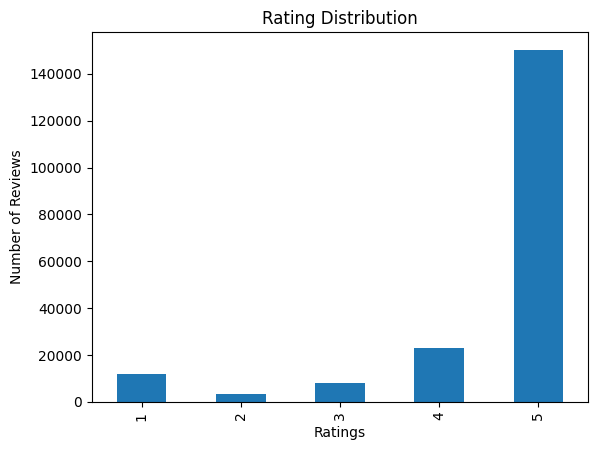

In [50]:
df['Ratings'].value_counts().sort_index().plot(kind='bar')
plt.title('Rating Distribution')
plt.xlabel('Ratings')
plt.ylabel('Number of Reviews')
plt.show()

In [51]:
df['review_length'] = df['Review'].astype(str).apply(len)

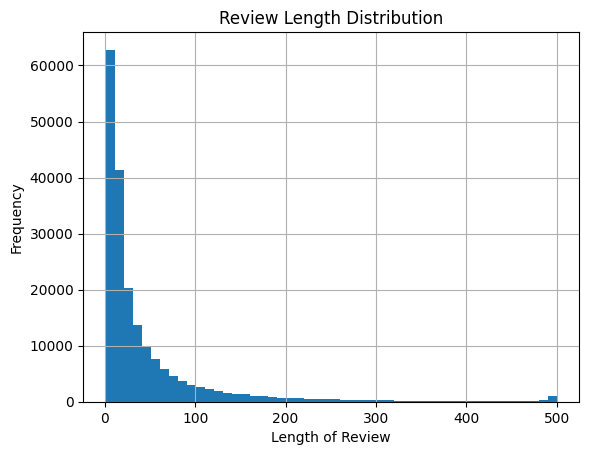

In [52]:
df['review_length'].hist(bins=50)
plt.title('Review Length Distribution')
plt.xlabel('Length of Review')
plt.ylabel('Frequency')
plt.show()

In [53]:
df['Review Date'] = pd.to_datetime(df['Review Date'])

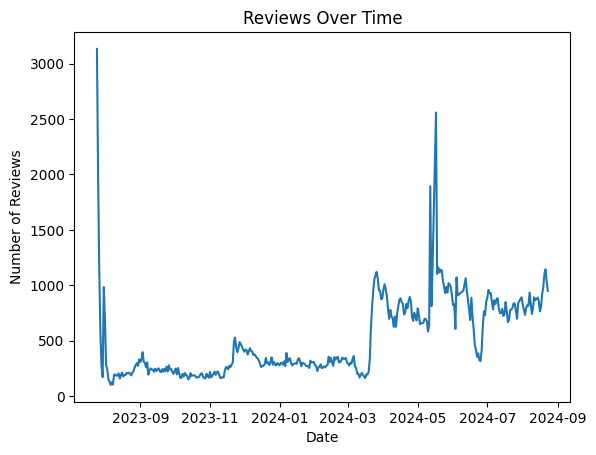

In [54]:
df.groupby(df['Review Date'].dt.date).size().plot()
plt.title('Reviews Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.show()

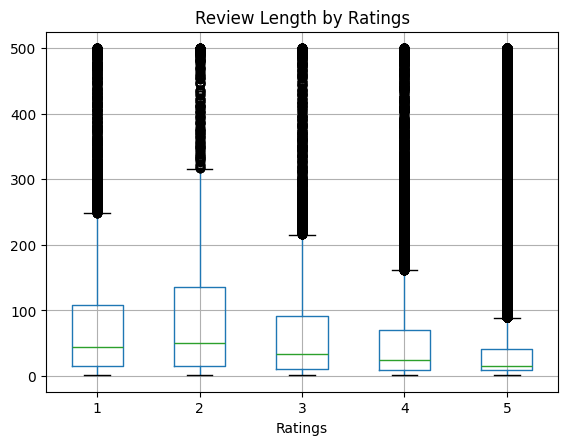

In [55]:
df.boxplot(column='review_length', by='Ratings')
plt.title('Review Length by Ratings')
plt.suptitle('')
plt.show()

In [56]:
!pip install textblob

In [57]:
from textblob import TextBlob

In [ ]:
df['polarity'] = df['Review'].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)
df['subjectivity'] = df['Review'].astype(str).apply(lambda x: TextBlob(x).sentiment.subjectivity)

In [ ]:
def get_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score == 0:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['polarity'].apply(get_sentiment)

In [ ]:
df['sentiment'].value_counts()

In [ ]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [ ]:
pd.crosstab(df['Ratings'], df['sentiment'])

In [ ]:
pd.crosstab(df['Ratings'], df['sentiment']).plot(kind='bar', stacked=True)
plt.title('Ratings vs Sentiment')
plt.show()

In [ ]:
df['subjectivity'].hist(bins=50)
plt.title('Subjectivity Distribution')
plt.show()

In [ ]:
!pip install wordcloud nltk

In [ ]:
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt

In [ ]:
nltk.download('stopwords')

In [ ]:
text = ' '.join(df['Review'].astype(str))

In [ ]:
stop_words = set(stopwords.words('english'))

filtered_words = [word for word in text.split() if word.lower() not in stop_words]

cleaned_text = ' '.join(filtered_words)

In [ ]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(cleaned_text)

plt.imshow(wordcloud)
plt.axis('off')
plt.title('Word Cloud of Reviews')
plt.show()

In [ ]:
positive_reviews = df[df['sentiment'] == 'Positive']

text_pos = ' '.join(positive_reviews['Review'].astype(str))

In [ ]:
filtered_words_pos = [word for word in text_pos.split() if word.lower() not in stop_words]

cleaned_text_pos = ' '.join(filtered_words_pos)

In [ ]:
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(cleaned_text_pos)

plt.imshow(wordcloud_pos)
plt.axis('off')
plt.title('Positive Reviews Word Cloud')
plt.show()

In [ ]:
from collections import Counter

word_counts = Counter(filtered_words)

common_words = word_counts.most_common(10)

words = [word[0] for word in common_words]
counts = [word[1] for word in common_words]

plt.bar(words, counts)
plt.title('Top 10 Keywords')
plt.xticks(rotation=45)
plt.show()